# Chromatin PTR analysis
March 18, 2024

Simple PTR analysis to compare deconvolved PTR to raw PTR.

Then compare deconvolved PTR to gene expression deconvovled PTR.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import glob

# PTR was fixed, so is in a separate directory
# outdir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
ptr_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin_ptr_fix/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(ptr_dir)


## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [5]:
peak_to_trough_analysis.compute_summary_metrics()

In [6]:
peak_to_trough_analysis.load_Fourier_scores()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


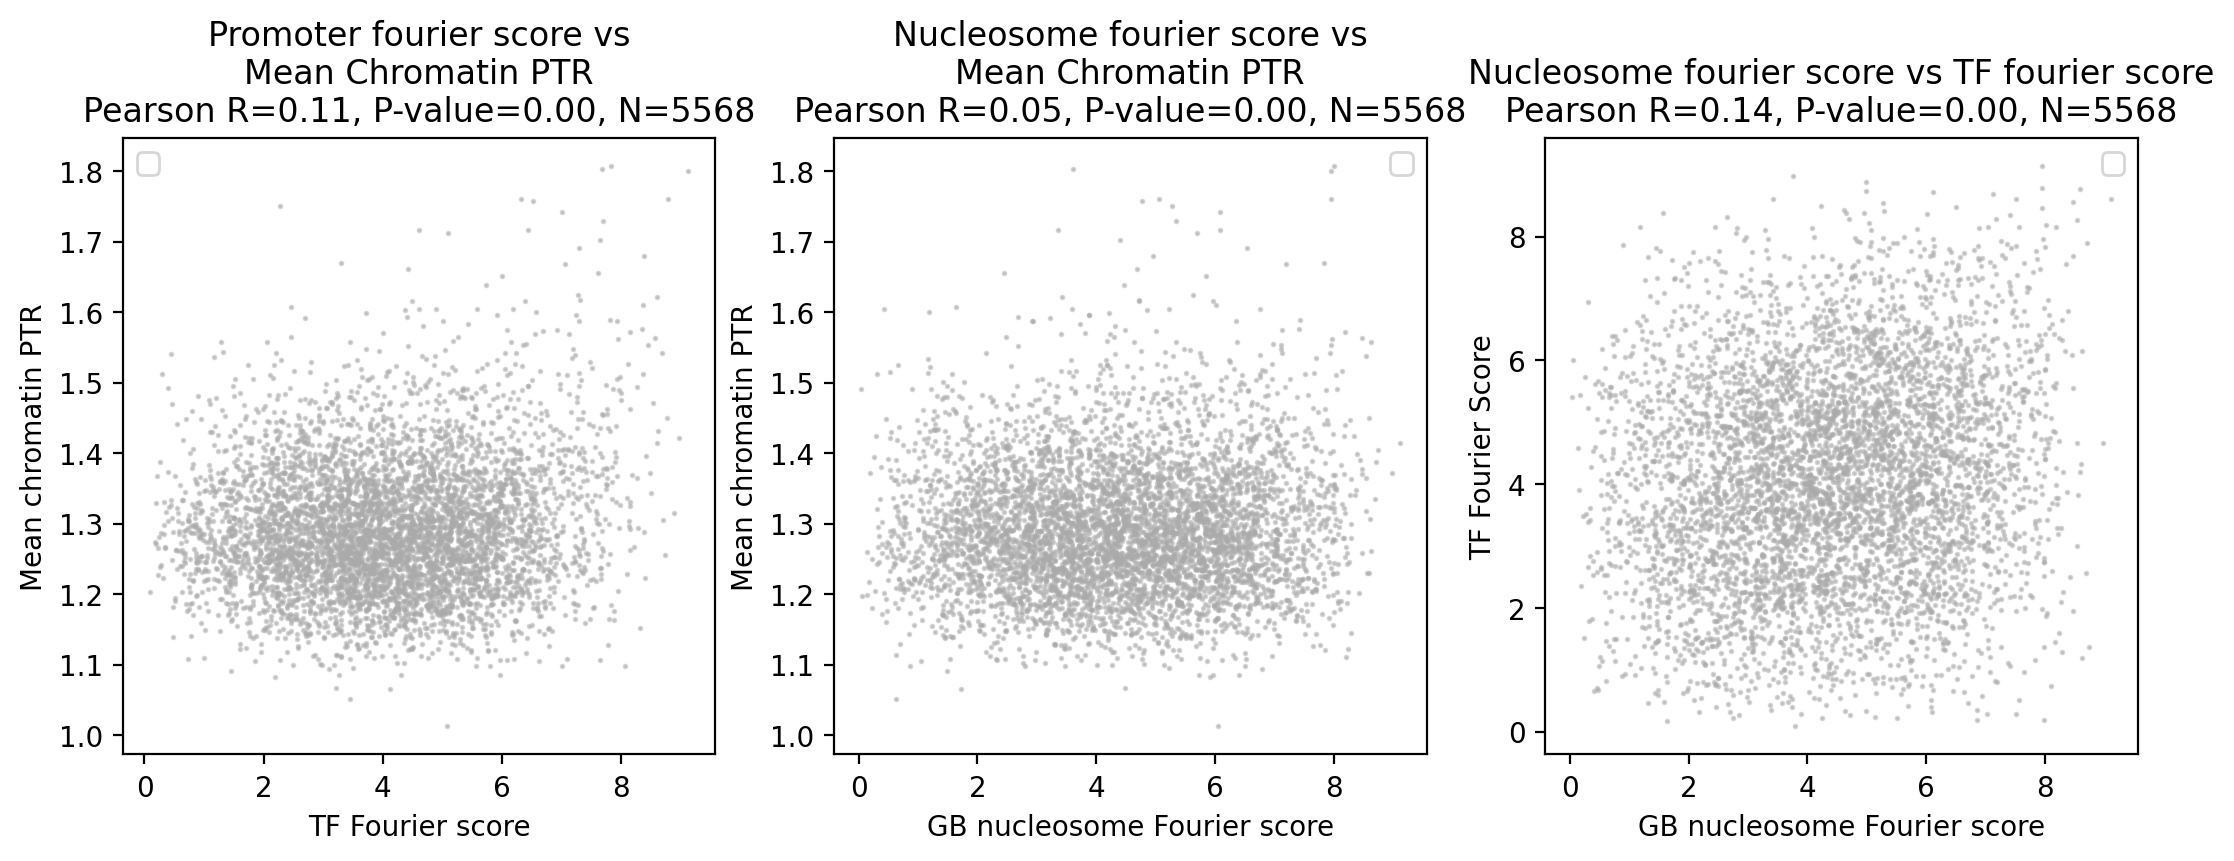

In [7]:
peak_to_trough_analysis.plot_ptr_comparison_to_fourier()

In [8]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

def compute_g_ptr(gene_name, replicate):
    config1 = load_yl_rg1_vst_config(replicate)

    chromatin_model1 = ChromatinModel(config1)
    chromatin_model1.load_mnase_gene(gene_name, log=False)
    chromatin_model1.create_deconvolution_bins()

    # Compute the raw PTR for the gene for both replicates
    from cc_src.peak_to_trough import compute_quantile_ptr

    mu0 = config1.intervals_wt1[0][0]

    # Compute the peak to trough ratio for non recovery timepoints
    non_RG1_G = chromatin_model1.G[chromatin_model1.timepoints > mu0, :]
    g_ptrs = np.apply_along_axis(lambda mat: compute_quantile_ptr(mat, 
        0.2, 0.8), 0, non_RG1_G)
    return g_ptrs


In [9]:
from src.timer import Timer
from cc_src.reference_data import load_analysis_genes

def get_g_ptrs_replicate(replicate):
    timer = Timer()
    
    geneset = load_analysis_genes()
    g_ptrs_df = None

    i = 0
    for orf_name, gene in geneset.iterrows():
        current_g_ptrs = compute_g_ptr(orf_name, replicate)

        if g_ptrs_df is None:        
            g_ptrs_df = pd.DataFrame(index=geneset.index.values,
                columns=np.arange(current_g_ptrs.shape[0]))

        g_ptrs_df.loc[orf_name, :] = current_g_ptrs

        if i % 100 == 0:
            print(f"{i}/{len(geneset)} - {timer.get_time()}")

        i += 1

    return g_ptrs_df


In [10]:
#g_ptrs_1_df = get_g_ptrs_replicate(1)

In [16]:
#g_ptrs_1_df.to_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep1.csv')
g_ptrs_1_df = pd.read_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep1.csv')
g_ptrs_1_df = g_ptrs_1_df.rename(columns={'Unnamed: 0': 'orf_name'}).set_index('orf_name')
g_ptrs_1_df.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067W-A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL067C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL064C-A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL064W,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL063C-A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
#g_ptrs_2_df = get_g_ptrs_replicate(2)

In [17]:
g_ptrs_2_df = pd.read_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep2.csv')
g_ptrs_2_df = g_ptrs_2_df.rename(columns={'Unnamed: 0': 'orf_name'}).set_index('orf_name')
g_ptrs_2_df.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067W-A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL067C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL064C-A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL064W,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YAL063C-A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
g_ptr_means_rep1 = g_ptrs_1_df.mean(axis=1)
metrics_df = peak_to_trough_analysis.metrics_df.copy()

metrics_df['mean_g_rep1'] = g_ptr_means_rep1

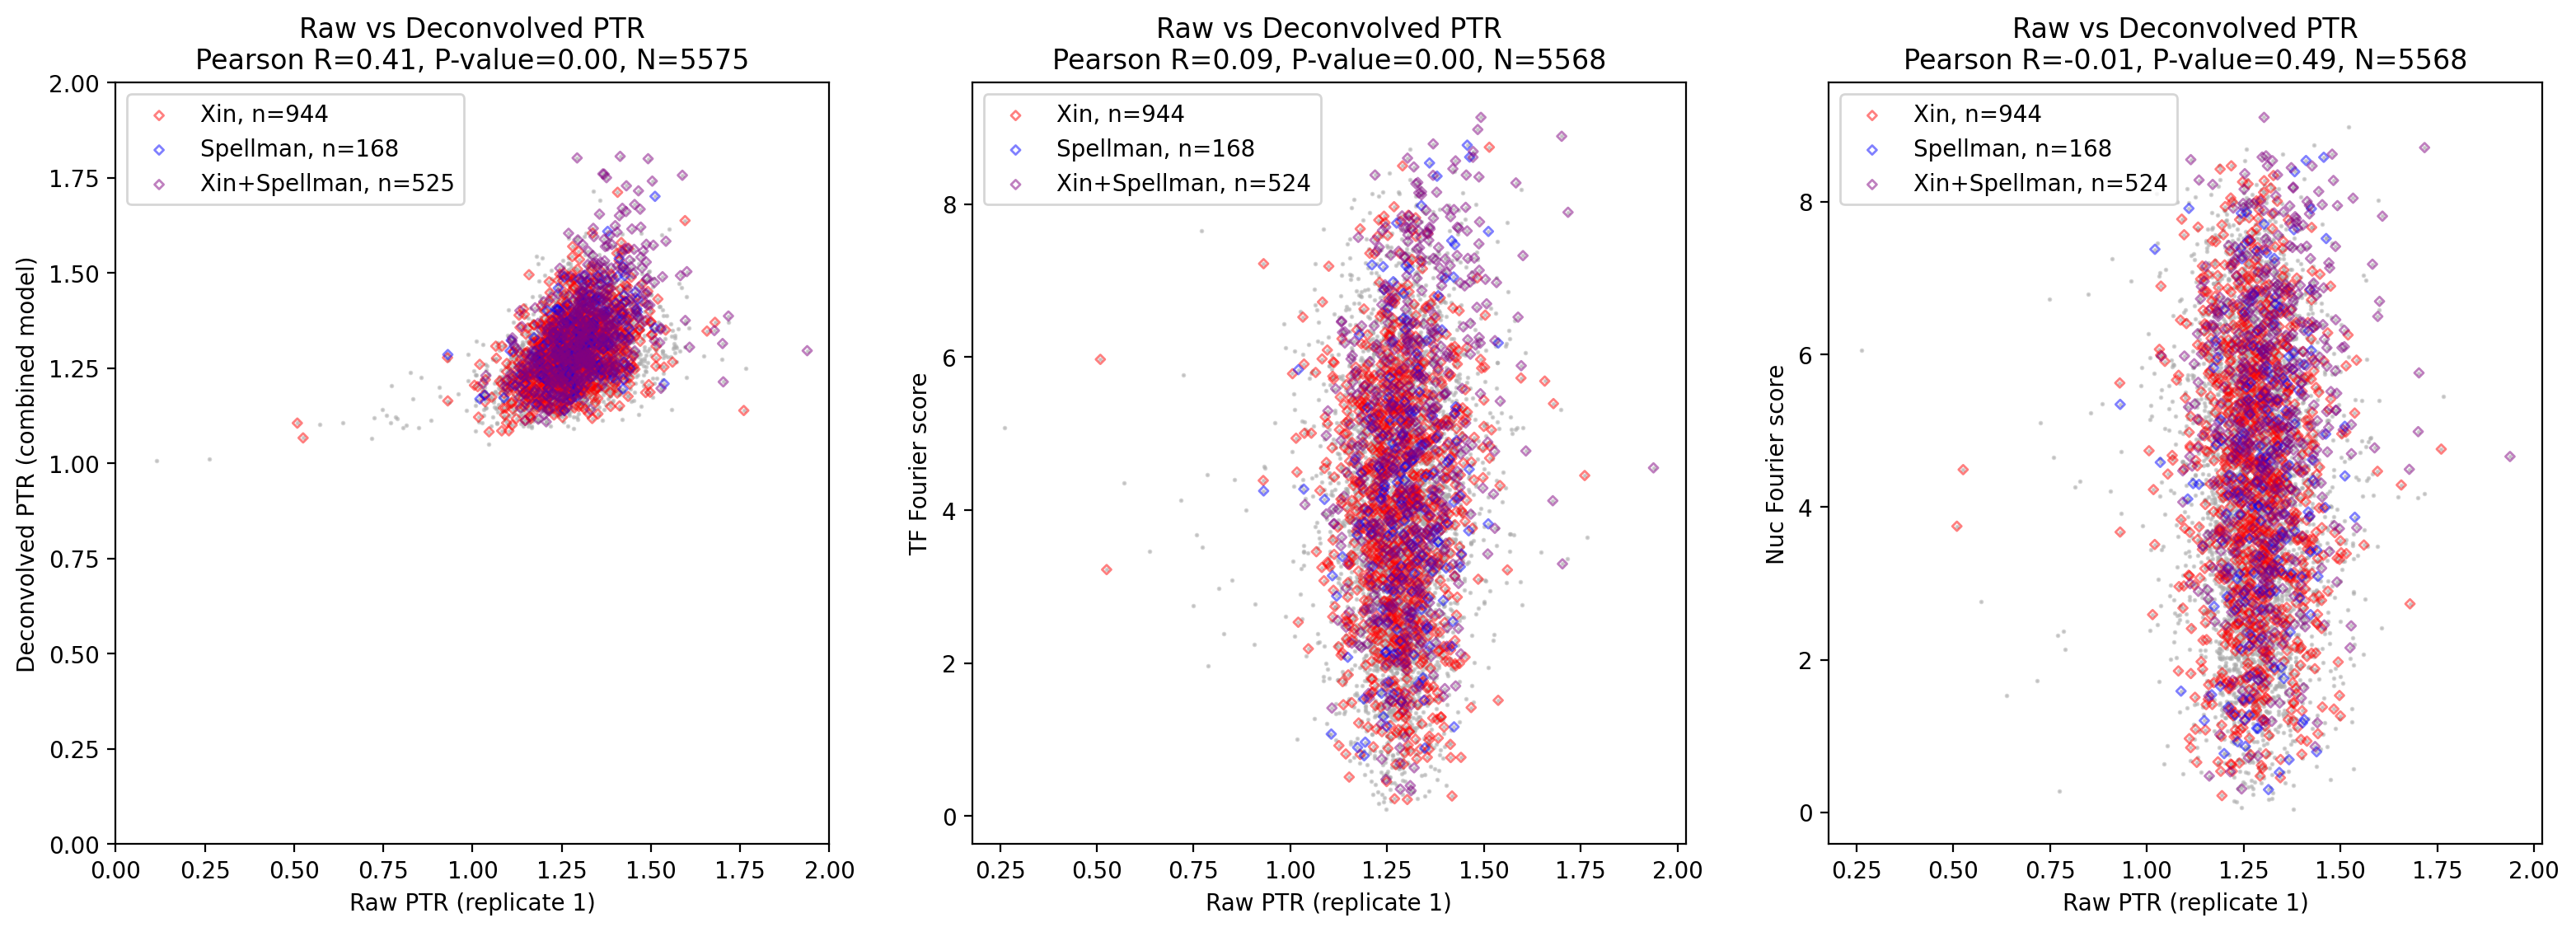

In [20]:
from cc_src.peak_to_trough_anaysis import plot_comparison_scatter, filter_index
from cc_src.reference_data import load_xin_1500_cc_orfs, load_spellman_orfs

xin_orfs = load_xin_1500_cc_orfs()
spellman_orfs = load_spellman_orfs()

both_xin_spellman = set(xin_orfs).intersection(spellman_orfs)
xin_only = set(xin_orfs).difference(both_xin_spellman)
spellman_only = set(spellman_orfs).difference(both_xin_spellman)
    
# Filter the highlighted orfs by the orfs we *do* have for deconvolved
# PTR means
filtered_both_xin_spellman = filter_index(both_xin_spellman, metrics_df.index.values)
filtered_both_xin = filter_index(xin_only, metrics_df.index.values)
filtered_both_spellman = filter_index(spellman_only, metrics_df.index.values)

plt.figure(figsize=(19, 6))
plt.subplot(1, 3, 1)
plot_comparison_scatter(metrics_df['mean_g_rep1'], metrics_df['mean_ptr'], 
                        "Raw vs Deconvolved PTR", "Raw PTR (replicate 1)", 
                        "Deconvolved PTR (combined model)",
                       highlighted_orfs=[
                          (filtered_both_xin, 'red', "Xin"),
                          (filtered_both_spellman, 'blue', "Spellman"),
                          (filtered_both_xin_spellman, 'purple', "Xin+Spellman"),
                       ])
plt.xlim(0, 2)
plt.ylim(0, 2)

plt.subplot(1, 3, 2)
tf_fourier_compare = peak_to_trough_analysis.tf_joined_df.copy()

# Filter the highlighted orfs by the fourier analysis set of gene orfs
filtered_both_xin_spellman = filter_index(both_xin_spellman, tf_fourier_compare.index.values)
filtered_both_xin = filter_index(xin_only, tf_fourier_compare.index.values)
filtered_both_spellman = filter_index(spellman_only, tf_fourier_compare.index.values)


tf_fourier_compare['mean_g_rep1'] = g_ptr_means_rep1
plot_comparison_scatter(tf_fourier_compare['mean_g_rep1'], 
                        tf_fourier_compare['Fourier_score'], 
                        "Raw vs Deconvolved PTR", "Raw PTR (replicate 1)", 
                        "TF Fourier score",
                        highlighted_orfs=[
                          (filtered_both_xin, 'red', "Xin"),
                          (filtered_both_spellman, 'blue', "Spellman"),
                          (filtered_both_xin_spellman, 'purple', "Xin+Spellman"),
                       ])

plt.subplot(1, 3, 3)
nuc_fourier_compare = peak_to_trough_analysis.nuc_joined_df.copy()
nuc_fourier_compare['mean_g_rep1'] = g_ptr_means_rep1
plot_comparison_scatter(nuc_fourier_compare['mean_g_rep1'], 
                        nuc_fourier_compare['Fourier_score'],
                        "Raw vs Deconvolved PTR", "Raw PTR (replicate 1)", 
                        "Nuc Fourier score", 
                       highlighted_orfs=[
                          (filtered_both_xin, 'red', "Xin"),
                          (filtered_both_spellman, 'blue', "Spellman"),
                          (filtered_both_xin_spellman, 'purple', "Xin+Spellman"),
                       ])


In [244]:
# Let's zoom into the raw vs deconvolved ptr plot and create the marginal distributions, we 
# would like to see how the individual subsets line up

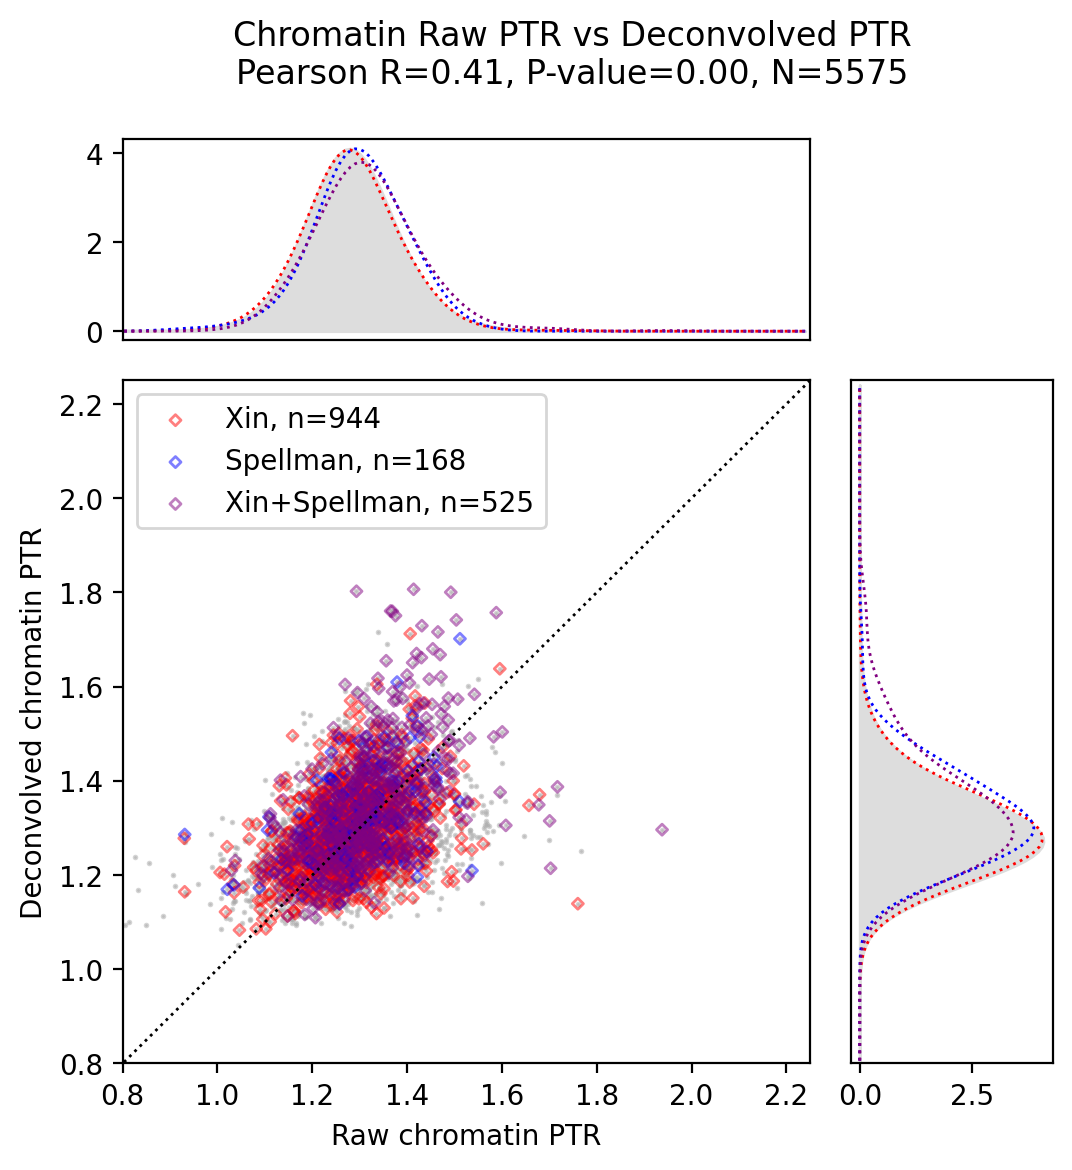

In [27]:

x, y = metrics_df['mean_g_rep1'], metrics_df['mean_ptr']

highlighted_orfs = create_highlighted_orfs_array(metrics_df)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(0.8, 2.25), ylim=(0.8, 2.25), 
                    title="Chromatin Raw PTR vs Deconvolved PTR",
                   xlabel="Raw chromatin PTR",
                   ylabel="Deconvolved chromatin PTR")

In [28]:
from cc_src.peak_to_trough_anaysis import load_deconvolved_ge_ptrs

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/'

deconvolved_ge_ptrs = load_deconvolved_ge_ptrs(outdir)

In [29]:
# Now, compare gene expression and chromatin PTR values, in the perfect case,
# all of the cell cycle genes will be in the top right quadrant. And the data will be a 1:1 line
# However, we know that the chromatin and gene expression do not correlate perfectly
# And there are many cell cycle genes that do no cycle their chromatin, genes without cycling
# expression, but cycling chromatin. And, we expect portions of the chromatin window
# to not be as cycling as others.


In [30]:
ge_chromatin_ptr_df = deconvolved_ge_ptrs.join(metrics_df[['mean_ptr']]).rename(
    columns={'ptr': 'gene_expression_ptr',
            'mean_ptr': 'chromatin_ptr'})
ge_chromatin_ptr_df = ge_chromatin_ptr_df.dropna()
ge_chromatin_ptr_df.head(2)

,gene,gene_expression_ptr,chromatin_ptr
orf_name,,,
YAL067W-A,YAL067W-A,1.0021,1.169257
YAL067C,SEO1,1.8564,1.404367


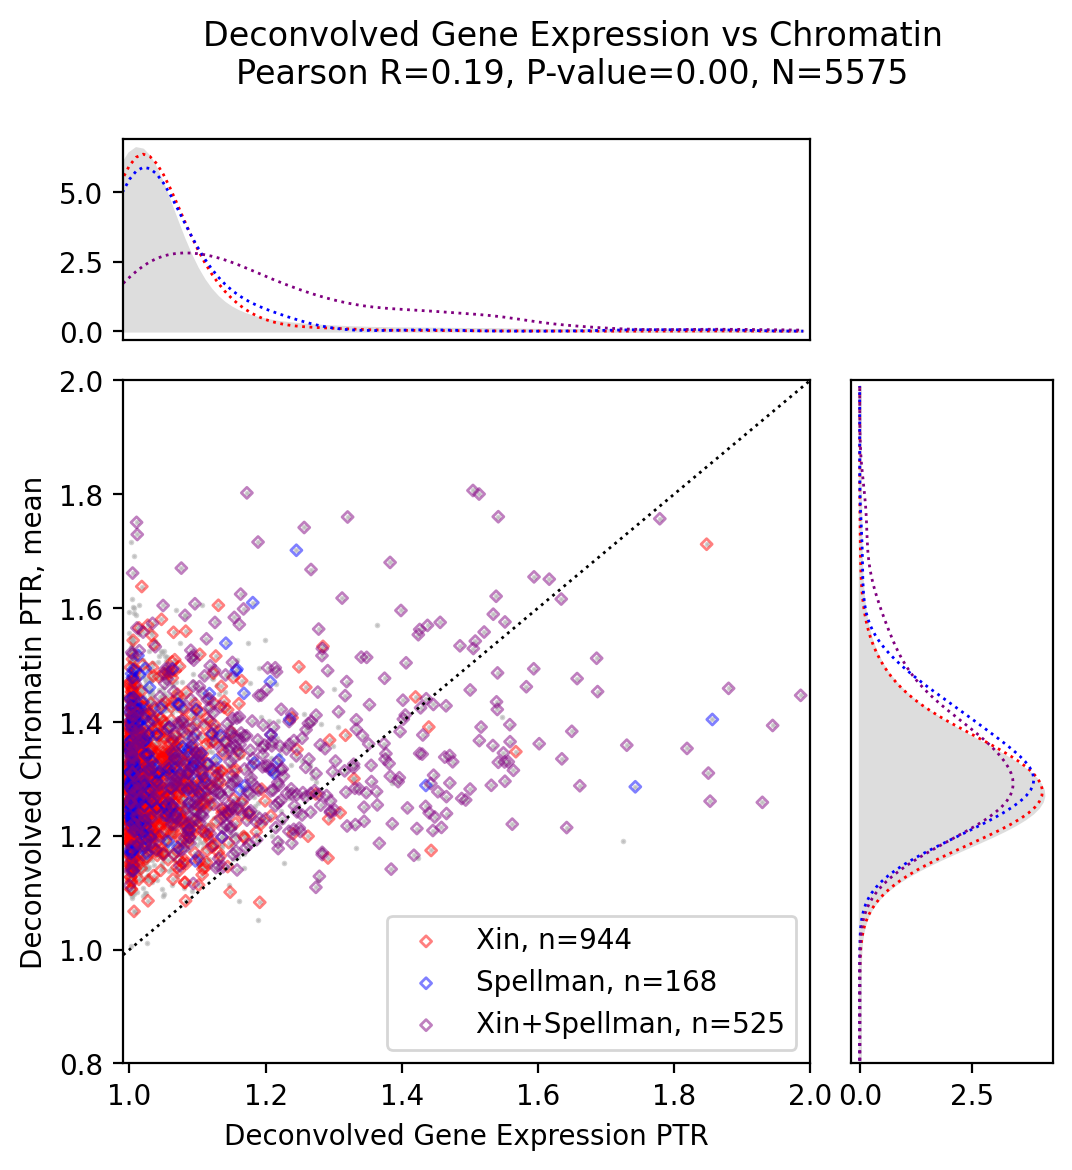

In [32]:

x, y = ge_chromatin_ptr_df['gene_expression_ptr'], ge_chromatin_ptr_df['chromatin_ptr']

highlighted_orfs = create_highlighted_orfs_array(ge_chromatin_ptr_df)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(0.99, 2), ylim=(0.8, 2), 
                    title="Deconvolved Gene Expression vs Chromatin",
                   xlabel="Deconvolved Gene Expression PTR",
                   ylabel="Deconvolved Chromatin PTR, mean")

In [359]:
peak_to_trough_analysis.undropped_ptrs_df.shape

(5578, 200)

In [452]:
# Grab the small fragments of the promoter region of each gene and
# let's perform the mean analysis again with this

config1 = load_yl_rg1_vst_config(replicate)
chromatin_model1 = ChromatinModel(config1)
    
ptr_imgs = peak_to_trough_analysis.ptr_imgs.copy()
ptr_imgs = ptr_imgs.astype(float)
ptr_imgs[np.isnan(ptr_imgs)] = 0

strand_corrected_ptr_imgs = ptr_imgs.copy()

# Correct for crick genes
# Flip all crick genes
crick_strand_genes = peak_to_trough_analysis.geneset.strand == '-'
crick_ptr_imgs = ptr_imgs[crick_strand_genes]
strand_corrected_ptr_imgs[crick_strand_genes] = np.fliplr(crick_ptr_imgs)


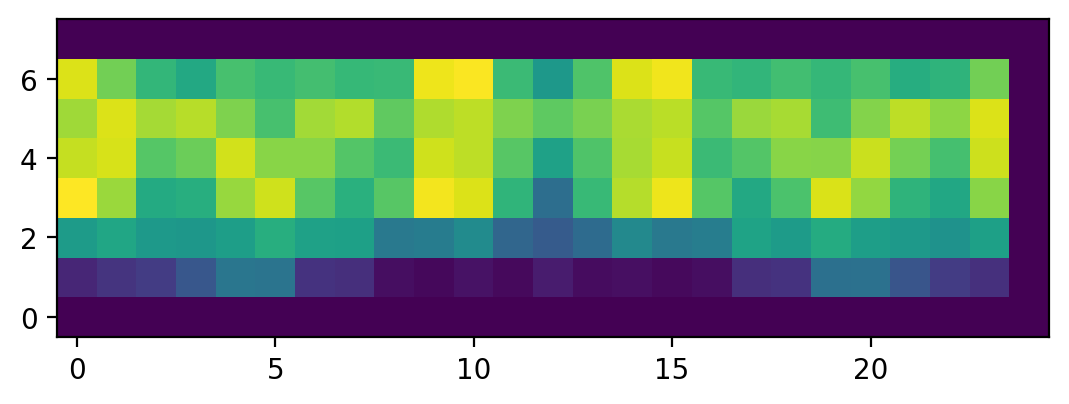

In [453]:
plt.imshow(ptr_imgs.sum(axis=0), origin='lower')

Text(0.5, 1.0, 'Average peak-to-trough values for all genes, N=5578')

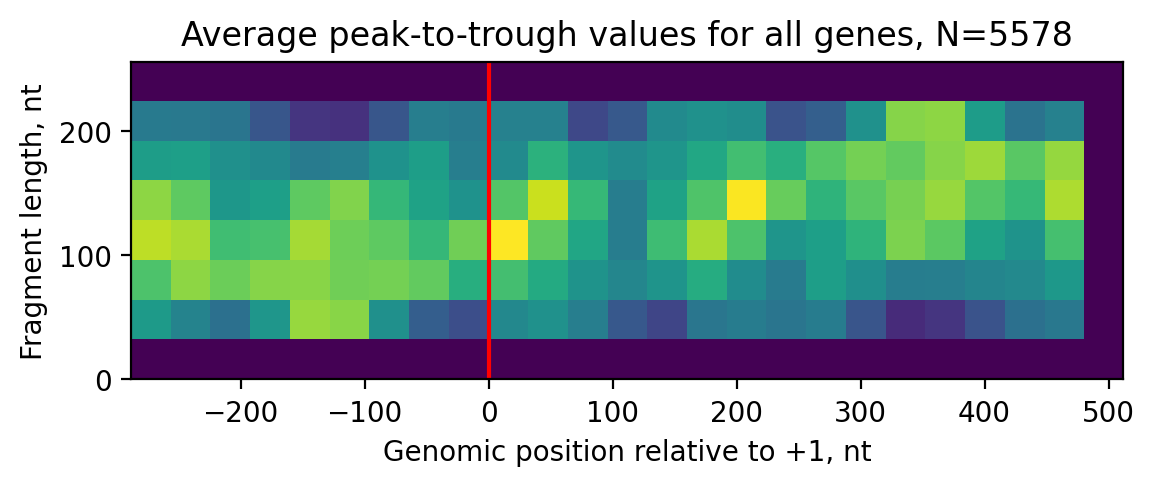

In [474]:
from cc_src.chromatin_metrics import yl_rep2_len_spans

plt.imshow(strand_corrected_ptr_imgs.sum(axis=0), origin='lower',
          extent=[-chromatin_model1.prom_len, chromatin_model1.gb_len,
                 0, chromatin_model1.max_y_len])

#chromatin_model1.bin_width, chromatin_model1.bin_height
#chromatin_model1.prom_len
#chromatin_model1.prom_len // chromatin_model1.bin_width
#chromatin_model1.gb_len // chromatin_model1.bin_width

smll, med, nuc_len = yl_rep2_len_spans()

#plt.axhline(smll[1], c='red')
plt.axvline(0, c='red')


#plt.axhline(nuc_len[0], c='red')
#plt.axhline(nuc_len[1], c='red')
#plt.axvline(0, c='red')
plt.xlabel("Genomic position relative to +1, nt")
plt.ylabel("Fragment length, nt")
plt.title(f"Average peak-to-trough values for all genes, N={len(ptr_imgs)}")

In [488]:
small_bins = 0, 100//chromatin_model1.bin_height
promoter_bins = 0, chromatin_model1.prom_len//chromatin_model1.bin_width

sm_frag_prom_imgs = strand_corrected_ptr_imgs[:, small_bins[0]:small_bins[1], 
    promoter_bins[0]:promoter_bins[1]]
sm_frag_prom_imgs.shape

(5578, 3, 9)

In [502]:
avg_sm_prom = sm_frag_prom_imgs.mean(axis=1).mean(axis=1)
avg_sm_ptrs = peak_to_trough_analysis.undropped_ptrs_df[[]].copy()
avg_sm_ptrs['mean_sm_prom_ptr'] = avg_sm_prom
avg_sm_ptrs['gene'] = peak_to_trough_analysis.geneset['gene']

avg_sm_ptrs.sort_values('mean_sm_prom_ptr', ascending=False)


,mean_sm_prom_ptr,gene
orf_name,,
YJL116C,2.233810,NCA3
YJR003C,2.144106,YJR003C
YLR050C,2.094904,YLR050C
YJL212C,2.088195,OPT1
YGL007C-A,2.087130,YGL007C-A
...,...,...
YMR170C,0.000011,ALD2
YJL138C,0.000011,TIF2
YOR246C,0.000000,YOR246C


In [568]:
from src.config import load_yl_rg1_vst_config
from cc_src.combined_chromatin_model import load_chromatin_model_from_disk

# Let's check where the PTR calculation may have a bug, no value in the 
# PTR window should be below 1.
gene_name = 'CLB2'
chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
chromatin_model = load_chromatin_model_from_disk(gene_name, chromatin_dir)


Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


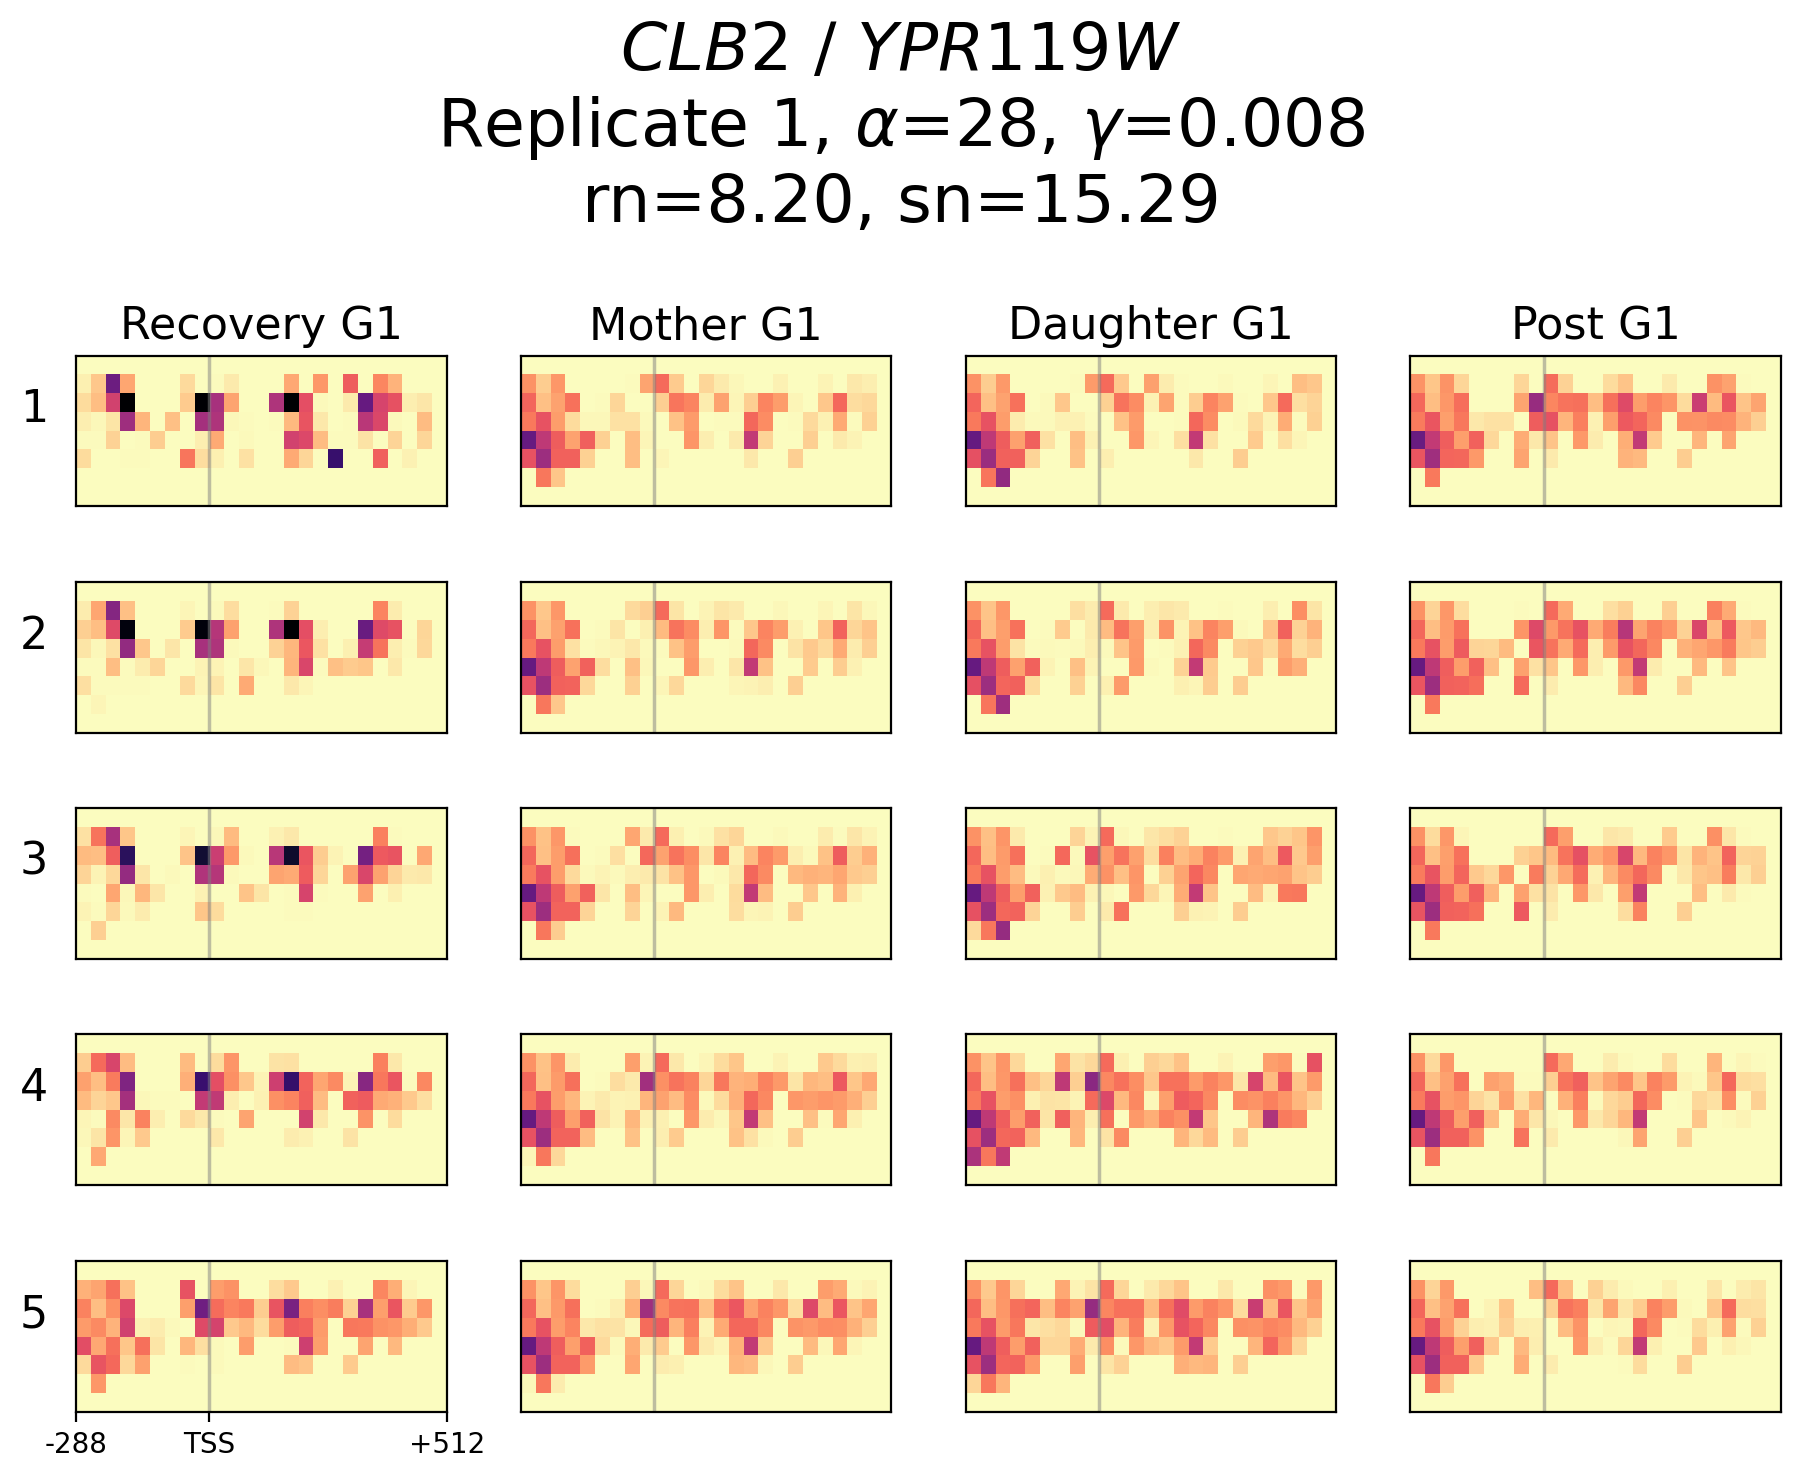

In [569]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped()

In [574]:
from cc_src.peak_to_trough import compute_ptr
chromatin_model.compute_ptr()

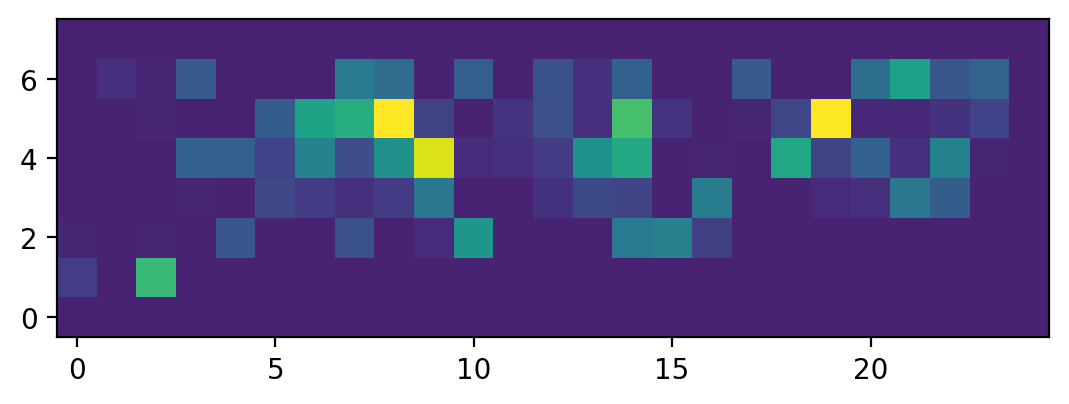

In [575]:
chromatin_model.f_ptrs.shape
chromatin_model.image_shape
ptrs_img = chromatin_model.f_ptrs.reshape(chromatin_model.image_shape)

plt.imshow(ptrs_img, vmin=0, vmax=10.0, origin='lower', cmap='viridis')